# ANN Regression Project
Professional Jupyter Notebook

## Project Introduction

In [5]:
print('ANN Regression Project')

ANN Regression Project


## Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Dense,Dropout

## Load Dataset

In [7]:
df=pd.read_csv('fashion_1M.csv')
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,brand,price_INR,discount_pct,effective_price_INR,rating,num_reviews,in_stock
0,1,Men,Apparel,Bottomwear,Track Pants,Red,Summer,2014,Formal,Wildcraft,5398,50,2699,3.6,7345,Yes
1,2,Men,Personal Care,Skin Care,Moisturiser,Silver,Summer,2011,Casual,Zara,2072,15,1761,4.1,5282,No
2,3,Men,Footwear,Shoes,Flats,Green,Summer,2022,Sports,Bata,3867,50,1934,4.2,8058,Yes
3,4,Women,Accessories,Jewellery,Ring,Brown,Summer,2016,Sports,Wrangler,4706,20,3765,4.8,10278,Yes
4,5,Boys,Apparel,Loungewear,Bathrobes,Black,Summer,2024,Casual,W,7489,0,7489,3.6,13243,Yes


## Dataset Overview

In [8]:
print(df.head());print(df.tail());print(df.shape);print(df.info());print(df.describe(include='all'))

   id gender masterCategory subCategory  articleType baseColour  season  year  \
0   1    Men        Apparel  Bottomwear  Track Pants        Red  Summer  2014   
1   2    Men  Personal Care   Skin Care  Moisturiser     Silver  Summer  2011   
2   3    Men       Footwear       Shoes        Flats      Green  Summer  2022   
3   4  Women    Accessories   Jewellery         Ring      Brown  Summer  2016   
4   5   Boys        Apparel  Loungewear    Bathrobes      Black  Summer  2024   

    usage      brand  price_INR  discount_pct  effective_price_INR  rating  \
0  Formal  Wildcraft       5398            50                 2699     3.6   
1  Casual       Zara       2072            15                 1761     4.1   
2  Sports       Bata       3867            50                 1934     4.2   
3  Sports   Wrangler       4706            20                 3765     4.8   
4  Casual          W       7489             0                 7489     3.6   

   num_reviews in_stock  
0         7345    

## Data Cleaning

In [9]:
df=df.drop_duplicates();df=df.dropna()

## EDA

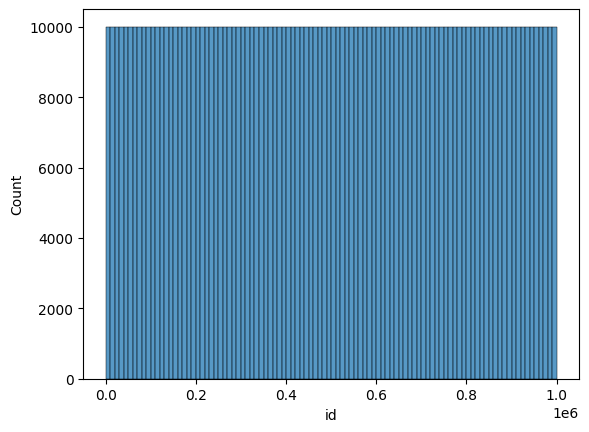

In [10]:
sns.histplot(df.select_dtypes(include='number').iloc[:,0]);plt.show()

## Feature Engineering

## Train-Test Split

In [19]:
target=df.columns[-1]
X=df.drop(columns=[target, 'id']).copy() # Drop 'id' column
y=df[target].copy()

# Encode categorical columns in X
for c in X.select_dtypes(include='object').columns:
 X[c]=LabelEncoder().fit_transform(X[c].astype(str))

# Encode the target variable y
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Ensure y_train and y_test are numerical, as the model expects.
# This step explicitly encodes them in case train_test_split returned original series by mistake.
if y_train.dtype == 'object':
    le_y = LabelEncoder()
    y_train = le_y.fit_transform(y_train)
    y_test = le_y.transform(y_test)

In [26]:
target=df.columns[-1]
X=df.drop(columns=[target, 'id']).copy() # Drop 'id' column
y=df[target].copy()

# Encode categorical columns in X
for c in X.select_dtypes(include='object').columns:
 X[c]=LabelEncoder().fit_transform(X[c].astype(str))

# Encode the target variable y
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

## Scaling

## Build ANN

In [27]:
model=Sequential([Dense(128,activation='relu',input_shape=(X_train.shape[1],)),Dropout(0.2),Dense(64,activation='relu'),Dense(1)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile

In [28]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

## Train

In [25]:
history=model.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 29s 1ms/step - loss: 0.1131 - mae: 0.2261 - val_loss: 0.1133 - val_mae: 0.2390
Epoch 2/5
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 42s 1ms/step - loss: 0.1131 - mae: 0.2261 - val_loss: 0.1130 - val_mae: 0.2287
Epoch 3/5
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 29s 1ms/step - loss: 0.1131 - mae: 0.2261 - val_loss: 0.1130 - val_mae: 0.2219
Epoch 4/5
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step - loss: 0.1131 - mae: 0.2261 - val_loss: 0.1130 - val_mae: 0.2270
Epoch 5/5
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 29s 1ms/step - loss: 0.1131 - mae: 0.2261 - val_loss: 0.1130 - val_mae: 0.2207


## Evaluate

## Graphs

In [30]:
pred=model.predict(X_test)
print('MAE',mean_absolute_error(y_test,pred))
# Calculate RMSE manually as 'squared' argument is not supported in this scikit-learn version
rmse = np.sqrt(mean_squared_error(y_test, pred))
print('RMSE', rmse)
print('R2',r2_score(y_test,pred))

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 758us/step
MAE 0.8341860175132751
RMSE 0.9097233344371362
R2 -6.344075679779053


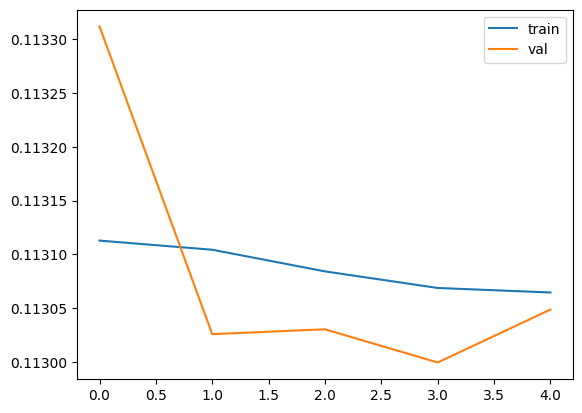

In [31]:
plt.plot(history.history['loss']);plt.plot(history.history['val_loss']);plt.legend(['train','val']);plt.show()

## Predictions

In [32]:
print(pred[:10])

[[ 0.24957982]
 [-0.13350354]
 [-0.09787052]
 [ 0.39020368]
 [ 0.24736033]
 [ 0.03979695]
 [ 0.13687243]
 [ 0.22553909]
 [-0.23382166]
 [ 0.61712146]]


## Save

In [33]:
model.save('fashion_ann_regression_model.h5')

## Load

## Conclusion

In [35]:
m=load_model('fashion_ann_regression_model.h5', compile=False)
m.compile(optimizer='adam',loss='mse',metrics=['mae'])
m.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,241 (40.00 KB)

 Trainable params: 10,241 (40.00 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
print('Regression pipeline completed.')

Regression pipeline completed.
